In [1]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

True Label : 5


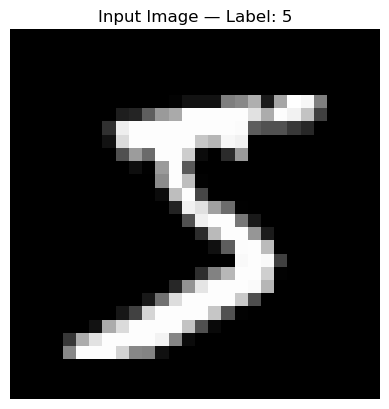

Input shape: (1, 784)


In [2]:
transform = transforms.Compose([transforms.ToTensor()])

dataset = datasets.MNIST(root='../data', train=True, download=False, transform=transform)

img, label = dataset[0]
print(f"True Label : {label}")

plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Input Image — Label: {label}")
plt.axis('off')
plt.show()

# Flatten to (784,) numpy array
X = img.numpy().reshape(1, 784)  # shape: (1, 784)
print(f"Input shape: {X.shape}")

## Initialize Random Weights


In [3]:
np.random.seed(42)

# Layer 1: 784 → 256
W1 = np.random.rand(784, 256) * 0.01
b1 = np.zeros((1,256))

# Layer 2: 256 → 120
W2 = np.random.randn(256, 120) * 0.01
b2 = np.zeros((1, 120))

# Layer 3: 120 → 10
W3 = np.random.randn(120, 10) * 0.01
b3 = np.zeros((1, 10))

print(f"W1 shape: {W1.shape}")
print(f"W2 shape: {W2.shape}")
print(f"W3 shape: {W3.shape}")


W1 shape: (784, 256)
W2 shape: (256, 120)
W3 shape: (120, 10)


### ReLU Activation


In [4]:
def relu(z):
    return np.maximum(0,z)

### Forward Pass


In [6]:
z1 = X @ W1 + b1
a1 = relu(z1)

z2 = a1 @ W2 + b2
a2 = relu(z2)         

z3 = a2 @ W3 + b3     

print(f"z1 shape : {z1.shape}")
print(f"a1 shape : {a1.shape}")
print(f"z2 shape : {z2.shape}")
print(f"a2 shape : {a2.shape}")
print(f"z3 shape : {z3.shape}  output logits")


z1 shape : (1, 256)
a1 shape : (1, 256)
z2 shape : (1, 120)
a2 shape : (1, 120)
z3 shape : (1, 10)  output logits


### Read the Output

In [9]:
def softmax(z):
    e = np.exp((z - z.max()))
    return e / e.sum()

probs = softmax(z3[0])
predicted = np.argmax(probs)

print(f"True label      : {label}")
print(f"Predicted class : {predicted}")
print(f"\nClass probabilities:")
for i, p in enumerate(probs):
    print(f"  Digit {i}: {p:.4f} ")


True label      : 5
Predicted class : 8

Class probabilities:
  Digit 0: 0.0996 
  Digit 1: 0.1002 
  Digit 2: 0.0994 
  Digit 3: 0.0999 
  Digit 4: 0.0994 
  Digit 5: 0.1005 
  Digit 6: 0.0998 
  Digit 7: 0.1003 
  Digit 8: 0.1006 
  Digit 9: 0.1002 
